In [1]:
import jax
print(f"JAX is using GPU: {jax.devices()}")

JAX is using GPU: [CudaDevice(id=0)]


In [2]:
NUM_DOF = 6
BATCH_SIZE = 1000


In [3]:
#These should be exactly same in main mpc
MAX_JOINT_TORQUE = 1.0
MAX_JOINT_DTORQUE = 1.5
MAX_JOINT_DDTORQUE = 2.0

NUM_STEPS = 30
TIMESTEP = 0.1
MAXITER_PROJECTION = 100
COV_COEFF_SCALAR = 1.0


In [4]:
max_joint_torque = MAX_JOINT_TORQUE
max_joint_dtorque = MAX_JOINT_DTORQUE
max_joint_ddtorque = MAX_JOINT_DDTORQUE
num = NUM_STEPS
timestep = TIMESTEP
maxiter_projection = MAXITER_PROJECTION
cov_coeff_scalar = COV_COEFF_SCALAR


In [5]:
timestep = TIMESTEP
num = NUM_STEPS
t_fin = timestep*num
t = t_fin

In [6]:
import os
current_working_directory = os.getcwd()
print(current_working_directory)


/home/alinjar/Training_jax/math_utils_aks_lab


In [7]:
# !pip install optax

In [8]:
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

In [9]:

import numpy as np 
import equinox as eqx
import jax
import jax.numpy as jnp

# from mlp_biped_torque_jax import MLP, MLPProjectionFilter
import optax
from functools import partial
# from jax_utilities.jax_loss import QPTrainer
from qp_jax_general import QP


In [10]:
from jaxopt import linear_solve
import numpy as onp

onp.random.seed(42)
A = onp.random.randn(3, 3)
b = onp.random.randn(3)

def matvec_A(x):
  return  jnp.dot(A, x)

sol = linear_solve.solve_normal_cg(matvec_A, b, tol=1e-5)
print(sol)

sol = linear_solve.solve_gmres(matvec_A, b, tol=1e-5)
print(sol)

sol = linear_solve.solve_bicgstab(matvec_A, b, tol=1e-5)
print(sol)

sol_ = jnp.linalg.solve(A, b)
print(sol)

[-0.11791424  0.23412363  0.9780952 ]
[-0.11791542  0.23412311  0.9780951 ]
[-0.11791545  0.23412418  0.97809505]
[-0.11791545  0.23412418  0.97809505]


In [11]:
# import jax.random as jr
# import lineax as lx

# matrix_key, vector_key = jr.split(jr.PRNGKey(0))
# matrix = jr.normal(matrix_key, (2, 2))
# vector = jr.normal(vector_key, (2,))

# print("matrix", matrix)
# print("vector", vector)

# operator = lx.MatrixLinearOperator(matrix)
# solution = lx.linear_solve(operator, vector, solver=lx.QR())

# print("solution", solution.value)
# print("solution", jnp.linalg.solve(matrix, vector))

In [12]:
# import sys
# parent_dir = os.path.join(os.getcwd(), '..') 

# # Add the parent directory to the system path
# sys.path.append(parent_dir)
# from math_utils_aks_lab.qp_jax_general import QP

In [13]:
num_dof = NUM_DOF

In [14]:
class cem_planner():

	def __init__(self, model=None, num_dof=None, num_batch=None, num_steps=None, timestep=None, maxiter_cem=None, num_elite=None, 
			     maxiter_projection=None, max_joint_inttorque = None ,max_joint_torque = None, 
				 max_joint_dtorque = None, max_joint_ddtorque = None):
		super(cem_planner, self).__init__()
	    

		self.num_dof = num_dof
		self.num_batch = num_batch
		self.t = timestep
		self.num = num_steps

		self.t_fin = self.num*self.t
		
		tot_time = jnp.linspace(0, self.t_fin, self.num)
		self.tot_time = tot_time
		tot_time_copy = tot_time.reshape(self.num, 1)

		self.P = jnp.identity(self.num) # Torque mapping 
		self.Pdot = jnp.diff(self.P, axis=0)/self.t # DTorque mapping
		self.Pddot = jnp.diff(self.Pdot, axis=0)/self.t # DDTorque mapping
		
		# self.P, self.Pdot, self.Pddot = bernstein_coeff_ordern_new(10, tot_time_copy[0], tot_time_copy[-1], tot_time_copy)


		self.P_jax, self.Pdot_jax, self.Pddot_jax = jnp.asarray(self.P), jnp.asarray(self.Pdot), jnp.asarray(self.Pddot)

		self.nvar_single = jnp.shape(self.P_jax)[1]
		self.nvar = self.nvar_single*self.num_dof 
  
		self.rho_ineq = 0.0005
		# self.rho_ineq = 0.05

		self.A_projection = jnp.identity(self.nvar)

		A_torque_ineq = self.get_A_torque()
		self.A_torque_ineq = jnp.asarray(A_torque_ineq) 

		A_dtorque_ineq = self.get_A_dtorque()
		self.A_dtorque_ineq = jnp.asarray(A_dtorque_ineq) 

		A_ddtorque_ineq = self.get_A_ddtorque()
		self.A_ddtorque_ineq = jnp.asarray(A_ddtorque_ineq)
  


		# Combined control matrix (like A_control in )
		self.A_control = jnp.vstack((
			self.A_torque_ineq,
			self.A_dtorque_ineq,
			self.A_ddtorque_ineq
		#	self.A_int_torque_ineq
		))

		A_eq = self.get_A_eq()
		self.A_eq = jnp.asarray(A_eq)

		A_torque, A_dtorque, A_ddtorque = self.get_A_torque_control()

		self.A_torque = jnp.asarray(A_torque)
		self.A_dtorque = jnp.asarray(A_dtorque)
		self.A_ddtorque = jnp.asarray(A_ddtorque)
		
		self.key= jax.random.PRNGKey(42)
		self.maxiter_projection = maxiter_projection
		self.maxiter_cem = maxiter_cem

		self.torque_max = max_joint_torque
		self.dtorque_max = max_joint_dtorque
		self.ddtorque_max = max_joint_ddtorque
		    
    	# Calculating number of Inequality constraints
		self.num_torque   = self.P.shape[0]       # number of time samples for torque 
		self.num_dtorque  = self.Pdot.shape[0]    # number of samples for rate of change)
		self.num_ddtorque = self.Pddot.shape[0]   # number of samples for double rate of change

		self.num_torque_constraints = 2 * self.num_torque * num_dof
		self.num_dtorque_constraints = 2 * self.num_dtorque * num_dof
		self.num_ddtorque_constraints = 2 * self.num_ddtorque * num_dof
		self.num_total_constraints = (self.num_torque_constraints + self.num_dtorque_constraints + 
								      self.num_ddtorque_constraints)
		self.num_total_constraints_per_dof = self.num_total_constraints / self.num_dof


		self.b_torque = jnp.hstack((
			self.torque_max * jnp.ones((self.num_batch, self.num_torque_constraints // 2)),
			self.torque_max * jnp.ones((self.num_batch, self.num_torque_constraints // 2))
		))

		self.b_dtorque = jnp.hstack((
			self.dtorque_max * jnp.ones((self.num_batch, self.num_dtorque_constraints // 2)),
			self.dtorque_max * jnp.ones((self.num_batch, self.num_dtorque_constraints // 2))
		))

		self.b_ddtorque = jnp.hstack((
			self.ddtorque_max * jnp.ones((self.num_batch, self.num_ddtorque_constraints // 2)),
			self.ddtorque_max * jnp.ones((self.num_batch, self.num_ddtorque_constraints // 2))
		))
        

		self.b_control = jnp.hstack((self.b_torque, self.b_dtorque, self.b_ddtorque))



		self.qp = QP(num_batch=self.num_batch,num_dof=self.num_dof,nvar=self.nvar,
			        num_total_constraints=self.num_total_constraints, rho_ineq=self.rho_ineq,
					A_projection=self.A_projection, A_control=self.A_control, A_eq=self.A_eq,
					b_control = self.b_control, maxiter_projection=self.maxiter_projection)

    
	def get_A_torque_control(self):


        
        # This is valid while not using knots and bernstein polynomials; directlly using velocity
		A_torque = jnp.kron(jnp.identity(self.num_dof), self.P )
		A_dtorque = jnp.kron(jnp.identity(self.num_dof), self.Pdot )
		A_ddtorque = jnp.kron(jnp.identity(self.num_dof), self.Pddot )

		return A_torque, A_dtorque, A_ddtorque	



	
	def get_A_torque(self):
		A_torque = jnp.vstack(( self.P, -self.P))
		A_torque_ineq = jnp.kron(jnp.identity(self.num_dof), A_torque )
		return A_torque_ineq

	def get_A_dtorque(self):
		A_dtorque = jnp.vstack(( self.Pdot, -self.Pdot))
		A_dtorque_ineq = jnp.kron(jnp.identity(self.num_dof), A_dtorque )
		return A_dtorque_ineq
	
	def get_A_ddtorque(self):
		A_ddtorque = jnp.vstack(( self.Pddot, -self.Pddot))
		A_ddtorque_ineq = jnp.kron(jnp.identity(self.num_dof), A_ddtorque )
		return A_ddtorque_ineq
	
	def get_A_eq(self):
		return jnp.kron(jnp.identity(self.num_dof), self.P[0])
	




In [15]:

def compute_xi_samples(key, xi_mean, xi_cov, nvar, num_batch ):
    key, subkey = jax.random.split(key)
    xi_samples = jax.random.multivariate_normal(key, xi_mean, xi_cov+0.003*jnp.identity(nvar), (num_batch, ))
    return xi_samples, key

In [16]:
cem = cem_planner(num_dof = NUM_DOF, num_batch=BATCH_SIZE, num_steps=NUM_STEPS, timestep=TIMESTEP,
                  maxiter_projection=MAXITER_PROJECTION, 
                  max_joint_torque= MAX_JOINT_TORQUE, max_joint_dtorque= MAX_JOINT_DTORQUE, max_joint_ddtorque=MAX_JOINT_DDTORQUE)

In [17]:
lamda_init = jnp.zeros((cem.num_batch, cem.nvar))
s_init = jnp.zeros((cem.num_batch, cem.num_total_constraints))



In [18]:

# Mean and covariance for a single variable
xi_mean_single = jnp.zeros(cem.nvar_single)
xi_cov_single = cov_coeff_scalar * jnp.eye(cem.nvar_single)

# Tiled mean and block-diagonal covariance (Kronecker product)
xi_mean = xi_mean_single.repeat(num_dof)
xi_cov = jnp.kron(jnp.eye(num_dof), xi_cov_single)

xi_samples, key = compute_xi_samples(cem.key, xi_mean, xi_cov, cem.nvar, BATCH_SIZE)

xi_samples = jnp.clip(xi_samples, a_min=-1.0, a_max=1.0)

# init_control = init_control.repeat(BATCH_SIZE, 1) 
# init_control = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
# Define the desired shape (6 elements)
control_shape = (NUM_DOF,)
key, subkey = jax.random.split(key)

# 2. Generate random values uniformly distributed between 0.0 (low) and 1.0 (high)
init_control = jax.random.uniform(
    key=subkey,
    shape=control_shape,
    minval=-1.0,
    maxval=1.0,
    dtype=jnp.float32
)

# init_control = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

print("init_control", init_control)

init_control = jnp.tile(init_control, (BATCH_SIZE, 1))

init_control [-0.16702724 -0.82705283 -0.03589582 -0.7513521   0.94439435 -0.36664724]


In [19]:
print("xi_samples", xi_samples.shape)
print("init_control_repeated", init_control.shape)

xi_samples (1000, 180)
init_control_repeated (1000, 6)


In [20]:

inp = jnp.hstack((init_control, xi_samples))


inp_mean, inp_std = inp.mean(), inp.std()

print("inp", inp.shape)

inp (1000, 186)


In [21]:

# --- Instantiate the QP Solver ---
qp_solver = cem.qp

s_init = jnp.maximum(
    jnp.zeros((cem.num_batch, cem.num_total_constraints)),
    -jnp.dot(cem.A_control, xi_samples.T).T + cem.b_control)

xi_projected, primal_residuals, fixed_point_residuals =qp_solver.compute_projection(xi_samples=xi_samples, 
                                                                                  state_term=init_control, 
                                                                                  lamda_init=lamda_init, 
                                                                                  s_init=s_init,
                                                                                  init_pos = None)




In [22]:
rank = qp_solver.get_rank()
jax.debug.print("Rank of cost_mat: {}", rank)

logdet = qp_solver.stable_logdet()
det_approx = jnp.exp(logdet)
jax.debug.print("Det_approx: {}", det_approx)

svd=qp_solver.get_svd()
print("len(svd)", len(svd))
print("max(svd)", max(svd))
print("min(svd)", min(svd))

eigvals = qp_solver.eigvals
print("len(eigvals)", len(eigvals))
print("max(eigvals)", max(eigvals))
print("min(eigvals)", min(eigvals))



Rank of cost_mat: 186
Det_approx: inf
len(svd) 186
max(svd) 160.48256
min(svd) 0.40941402
len(eigvals) 186
max(eigvals) (160.48233+0j)
min(eigvals) (-0.40941152+0j)


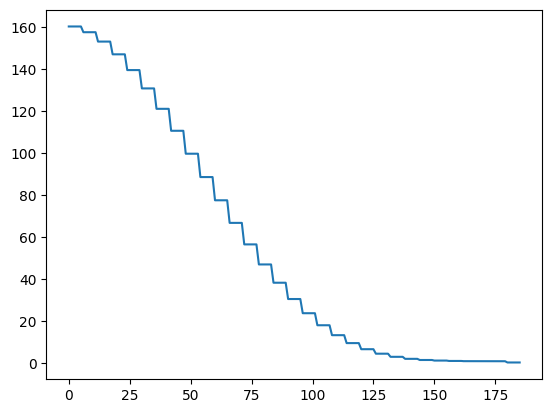

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(svd)
plt.show()


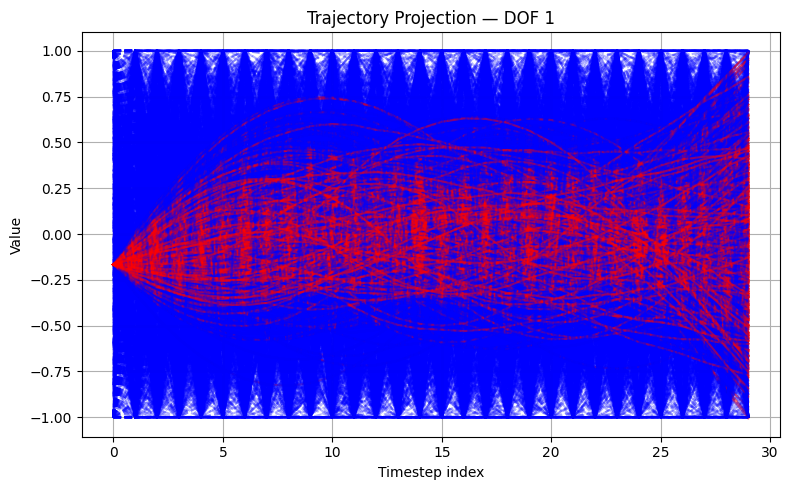

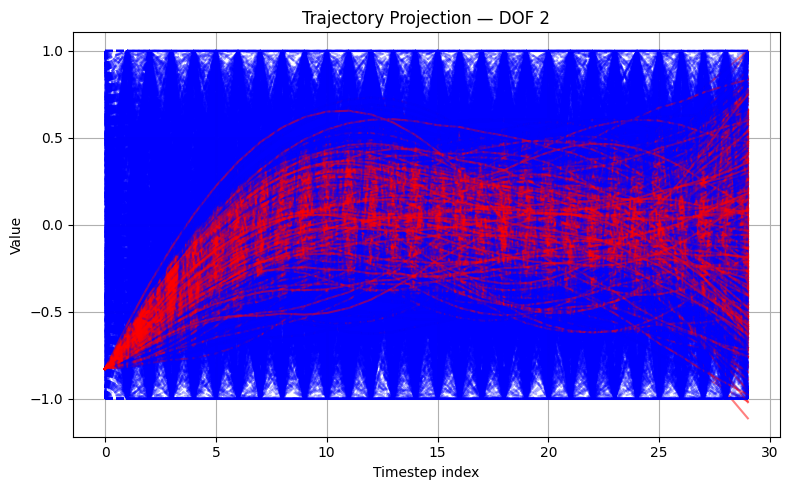

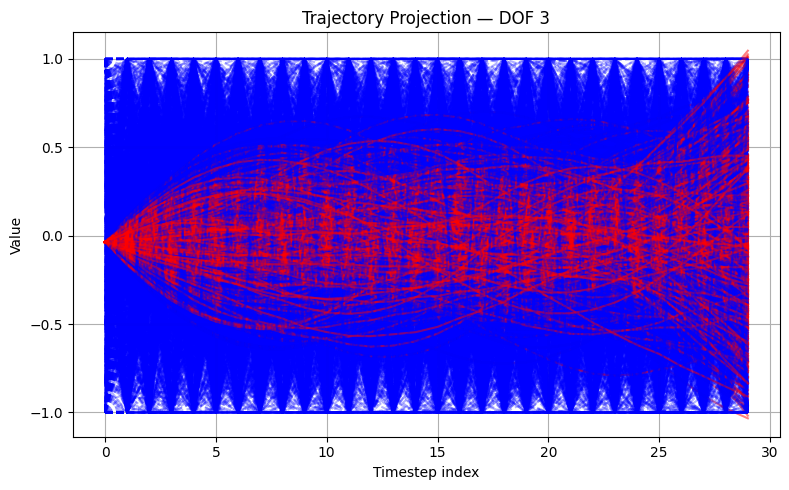

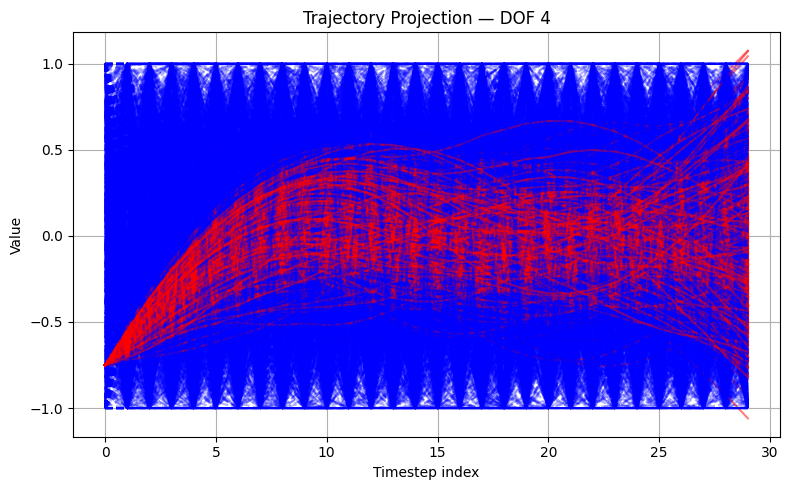

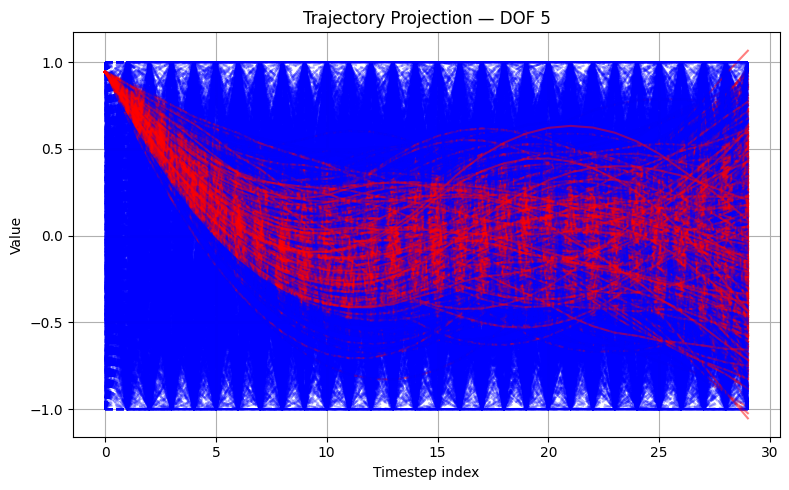

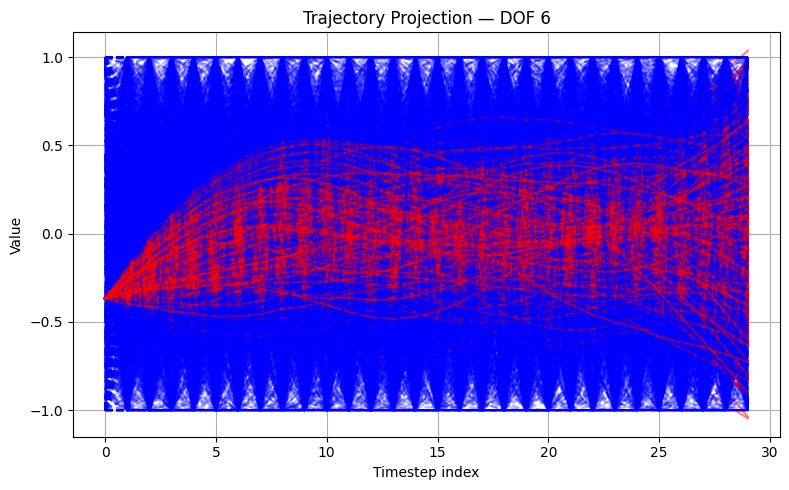

In [24]:
import matplotlib.pyplot as plt
import torch

# Shapes
batch_size, total_dim = xi_samples.shape
# set your actual DOF count
num = total_dim // num_dof

# Reshape to (batch_size, num_dof, num)
xi_s = xi_samples.reshape(batch_size, num_dof, num)
xi_p = xi_projected.reshape(batch_size, num_dof, num)

# Plot all samples for each DOF
for d in range(num_dof):
    plt.figure(figsize=(8, 5))
    for i in range(batch_size):
        plt.plot(xi_s[i, d], color='blue', linestyle='--', alpha=0.3)
        plt.plot(xi_p[i, d], color='red', alpha=0.5)
    plt.title(f"Trajectory Projection — DOF {d+1}")
    plt.xlabel("Timestep index")
    plt.ylabel("Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [25]:
print("primal_residuals", primal_residuals.shape)
print("fixed_point_residuals", fixed_point_residuals.shape)
print("primal_residuals end iter", jnp.mean(primal_residuals[-1,:]))
print("fixed_point_residuals end iter", jnp.mean(fixed_point_residuals[-1,:]))


primal_residuals (100, 1000)
fixed_point_residuals (100, 1000)
primal_residuals end iter 0.6547745
fixed_point_residuals end iter 0.12441564


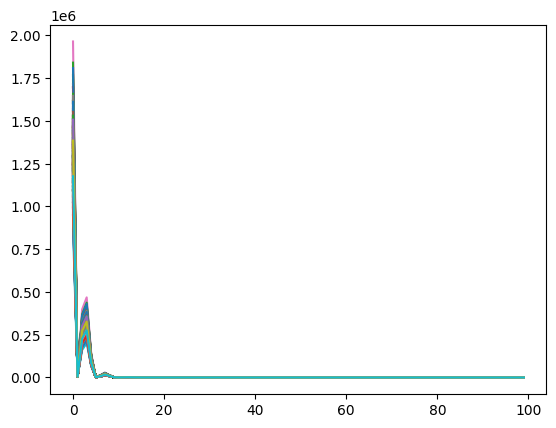

In [26]:
%matplotlib inline
plt.plot(primal_residuals)
plt.show()

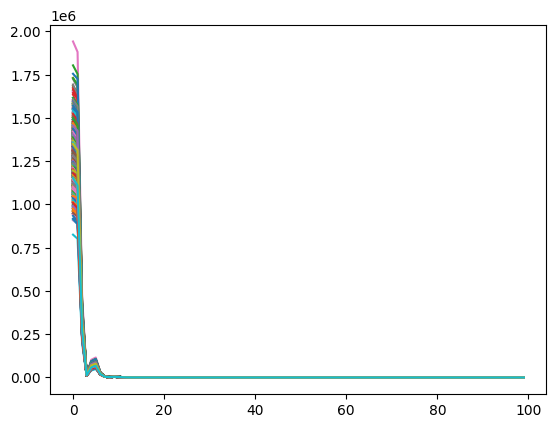

In [27]:
%matplotlib inline
plt.plot(fixed_point_residuals)
plt.show()